# Cassava Leaf Disease Classification

This project builds and benchmarks three neural-network classifiers — a custom-built CNN, a pretrained EfficientNet, and a LoRA-adapted Vision Transformer — on a real-world cassava leaf disease dataset collected in African farming communities. A key focus is how different class-imbalance correction strategies affect the detection of rare but destructive diseases.

| | |
|---|---|
| **Dataset** | Cassava Leaf Disease (21,397 field-collected images, 5 classes) |
| **Models** | CassavaCNN (custom) · EfficientNet-V2-S · Swin-Tiny + LoRA |
| **Strategies** | Option A: FocalLoss + WeightedRandomSampler · Option B: WeightedCE + LabelSmoothing |
| **Primary Metric** | Macro-F1 (accounts for severe class imbalance: CMD 61.5%, CBB 5.1%) |
| **Device** | Apple Silicon MPS (M1/M2/M3/M4) |


## 1. Project Setup

In [1]:
import sys
import json
import shutil
import warnings
import time
from pathlib import Path

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix

from codes.config import (
    SEED, NUM_CLASSES, INPUT_SIZE,
    TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT,
    BATCH_SIZE, NUM_EPOCHS, WARMUP_LR, LEARNING_RATE,
    WEIGHT_DECAY, NUM_WORKERS, PATIENCE,
    FOCAL_GAMMA, LABEL_SMOOTHING,
    MIXUP_ALPHA, CUTMIX_ALPHA,
    DATA_DIR, IMAGE_DIR, MODELS_DIR, RESULTS_DIR,
)
from codes.utils import set_seed, get_device, count_parameters
from codes.data_handler import (
    CLASS_NAMES, load_label_map, CassavaDataset,
    compute_class_weights, build_weighted_sampler, per_class_f1_report,
)
from codes.model import build_model
from codes.train import Trainer
from codes.evaluate import Evaluator
from codes.loss import build_criterion
from codes.gradcam import show_gradcam, show_gradcam_grid

set_seed(SEED)
DEVICE = get_device()

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device  : {DEVICE}')
print(f'Seed    : {SEED}')
print(f'Data    : {DATA_DIR}')
print(f'Classes : {NUM_CLASSES}')

Device  : mps
Seed    : 42
Data    : /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/cassava-leaf-dataset
Classes : 5


## 2. Dataset Exploration

In [2]:
disease_names = load_label_map(DATA_DIR)
class_name_list = [disease_names[i] for i in range(NUM_CLASSES)]

print('Disease classes:')
for k, v in sorted(disease_names.items()):
    print(f'  {k}: {v}')

train_df = pd.read_csv(DATA_DIR / 'train.csv')
for col in ('image_id', 'img_name', 'image', 'filename'):
    if col in train_df.columns and col != 'image_id':
        train_df = train_df.rename(columns={col: 'image_id'})
        break
train_df['image_id'] = train_df['image_id'].astype(str)

print(f'\nTotal images : {len(train_df):,}')
print(f'Columns      : {list(train_df.columns)}')
display(train_df.head())

Disease classes:
  0: Cassava Bacterial Blight (CBB)
  1: Cassava Brown Streak Disease (CBSD)
  2: Cassava Green Mottle (CGM)
  3: Cassava Mosaic Disease (CMD)
  4: Healthy

Total images : 21,397
Columns      : ['image_id', 'label']


,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


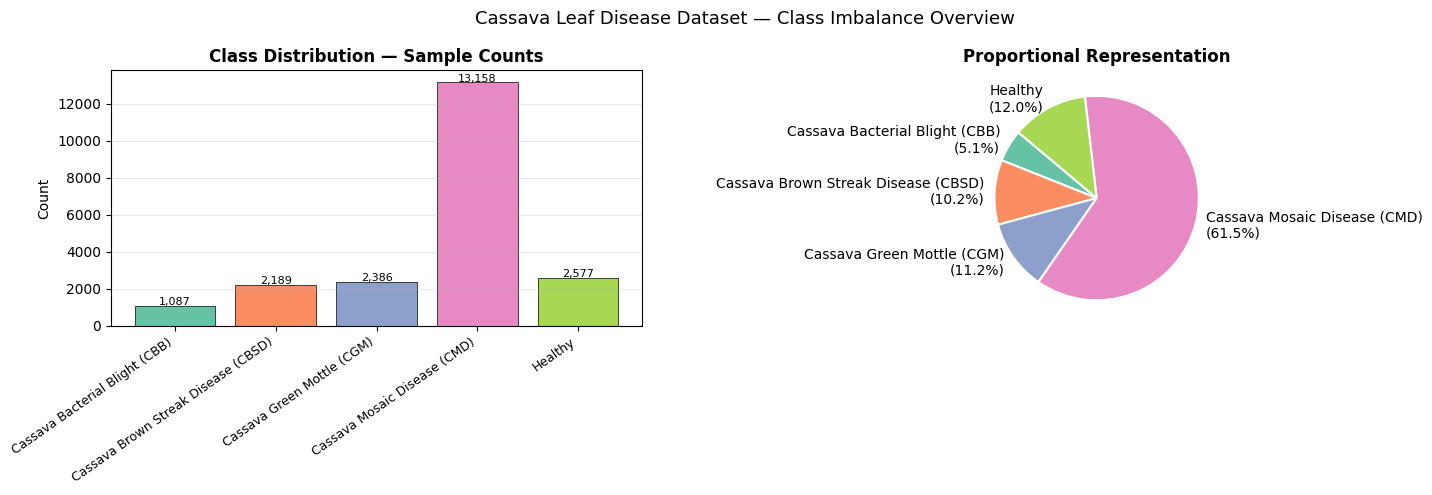

,Class,Count,Percentage
0,Cassava Bacterial Blight (CBB),1087,5.1
1,Cassava Brown Streak Disease (CBSD),2189,10.2
2,Cassava Green Mottle (CGM),2386,11.2
3,Cassava Mosaic Disease (CMD),13158,61.5
4,Healthy,2577,12.0



Class imbalance ratio (max/min): 12.1x


In [3]:
class_counts = train_df['label'].value_counts().sort_index()
labels_list  = [disease_names[i] for i in class_counts.index]
palette      = sns.color_palette('Set2', NUM_CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(range(len(class_counts)), class_counts.values, color=palette, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(class_counts)))
axes[0].set_xticklabels(labels_list, rotation=35, ha='right', fontsize=9)
axes[0].set_title('Class Distribution — Sample Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=8)

axes[1].pie(
    class_counts.values,
    labels=[f'{n}\n({c/class_counts.sum()*100:.1f}%)' for n, c in zip(labels_list, class_counts.values)],
    colors=palette, startangle=140, pctdistance=0.85,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Proportional Representation', fontsize=12, fontweight='bold')

plt.suptitle('Cassava Leaf Disease Dataset — Class Imbalance Overview', fontsize=13)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

dist_summary = pd.DataFrame({
    'Class': labels_list,
    'Count': class_counts.values,
    'Percentage': (class_counts.values / class_counts.sum() * 100).round(1)
})
display(dist_summary)
print(f'\nClass imbalance ratio (max/min): {class_counts.max() / class_counts.min():.1f}x')

## 3. Outlier Detection — Three-Stage Pipeline

Raw field images often contain corrupt files, photographs of soil or sky with no leaf, and samples that look nothing like their assigned class. The pipeline below removes these before training so the models learn from clean data only:

| Stage | Method | What It Catches |
|---|---|---|
| 1 | File integrity check | Corrupt, truncated, blank, near-black, or near-white images |
| 2 | Leaf-content filter | Images with too little green vegetation (not actually a leaf photo) |
| 3 | Per-class embedding outlier removal | ResNet-50 features + per-class IsolationForest detects mislabelled or atypical samples |


In [4]:
from codes.outlier_handler import (
    run_outlier_pipeline, visualizeflagged_images,
    plot_green_fraction_distribution, plot_anomaly_score_distribution,
    apply_removals,
)

clean_csv = RESULTS_DIR / 'train_clean.csv'

if clean_csv.exists():
    print(f'Clean dataset already exists at {clean_csv}. Loading...')
    df_clean = pd.read_csv(clean_csv)
    stats_df = flagged2 = feats = emb_ids = scores = flagged3 = None
else:
    per_class_thr = -0.15
    skip_stage3   = False

    df_clean, stats_df, flagged2, feats, emb_ids, scores, flagged3 = run_outlier_pipeline(
        csv_path      = str(DATA_DIR / 'train.csv'),
        img_dir       = str(IMAGE_DIR),
        device        = str(DEVICE),
        per_class_thr = per_class_thr,
        skip_stage3   = skip_stage3,
    )

print(f'\nDataset size after Stage 1: {len(df_clean):,}')

Clean dataset already exists at /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/results/train_clean.csv. Loading...

Dataset size after Stage 1: 21,280


In [5]:
stage1_log = RESULTS_DIR / 'removed_stage1_integrity.csv'
if stage1_log.exists():
    s1_df = pd.read_csv(stage1_log)
    print(f'Stage 1 auto-removed: {len(s1_df):,}')
    display(s1_df['reason'].str.split('(').str[0].value_counts().to_frame())
else:
    print('Stage 1: all images passed integrity check.')

if flagged2 is not None and not flagged2.empty:
    print(f'\nStage 2 flagged: {len(flagged2):,}')
    display(flagged2[['image_id', 'label', 'green_fraction', 'fail_reasons']].head(10))
    visualizeflagged_images(flagged2, str(IMAGE_DIR), title='Stage 2 — Low Vegetation Content')
    if stats_df is not None:
        plot_green_fraction_distribution(stats_df, flagged2,
                                         save_path=str(RESULTS_DIR / 'stage2_green_dist.png'))

if flagged3 is not None and scores is not None and len(scores) > 0:
    print(f'Stage 3 flagged: {len(flagged3):,}')
    plot_anomaly_score_distribution(scores, thr=-0.15,
                                     save_path=str(RESULTS_DIR / 'stage3_anomaly_dist.png'))
    visualizeflagged_images(flagged3, str(IMAGE_DIR), title='Stage 3 — Embedding Outliers')

if flagged2 is not None:
    remove_ids = []
    if not flagged2.empty:
        remove_ids.extend(flagged2['image_id'].tolist())
    if flagged3 is not None and not flagged3.empty:
        remove_ids.extend(flagged3['image_id'].tolist())
    df_clean = apply_removals(df_clean, remove_ids, str(clean_csv))
else:
    print(f'Using cached clean dataset ({len(df_clean):,} images).')

print(f'\nFinal clean dataset: {len(df_clean):,} images')

Stage 1: all images passed integrity check.
Using cached clean dataset (21,280 images).

Final clean dataset: 21,280 images


## 4. Data Preparation

In [6]:
val_test_fraction = VAL_SPLIT + TEST_SPLIT
train_indices, temp_indices = train_test_split(
    range(len(df_clean)),
    test_size=val_test_fraction,
    random_state=SEED,
    stratify=df_clean['label']
)

test_fraction_of_temp = TEST_SPLIT / val_test_fraction
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=test_fraction_of_temp,
    random_state=SEED,
    stratify=df_clean.iloc[temp_indices]['label']
)

split_df = {
    'train': df_clean.iloc[train_indices].reset_index(drop=True),
    'val':   df_clean.iloc[val_indices].reset_index(drop=True),
    'test':  df_clean.iloc[test_indices].reset_index(drop=True),
}

print('Stratified splits:')
for split_name, df_split in split_df.items():
    pct = len(df_split) / len(df_clean) * 100
    print(f'  {split_name:6s}: {len(df_split):,} ({pct:.1f}%)')

Stratified splits:
  train : 17,024 (80.0%)
  val   : 2,128 (10.0%)
  test  : 2,128 (10.0%)


In [7]:
lkw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=False)

loaders = {
    'val': DataLoader(
        CassavaDataset(split_df['val'],  IMAGE_DIR, augment=False, image_size=INPUT_SIZE),
        shuffle=False, **lkw
    ),
    'test': DataLoader(
        CassavaDataset(split_df['test'], IMAGE_DIR, augment=False, image_size=INPUT_SIZE),
        shuffle=False, **lkw
    ),
}

imgs, lbs = next(iter(loaders['val']))
print(f'Batch shape  : {imgs.shape}')
print(f'Label shape  : {lbs.shape}')
print(f'Pixel range  : [{imgs.min():.3f}, {imgs.max():.3f}]')
print(f'Val batches  : {len(loaders["val"])}')
print(f'Test batches : {len(loaders["test"])}')

Batch shape  : torch.Size([64, 3, 224, 224])
Label shape  : torch.Size([64])
Pixel range  : [-2.118, 2.640]
Val batches  : 34
Test batches : 34


## 5. CassavaCNN — Custom Architecture

CassavaCNN is a purpose-built residual network trained entirely from scratch — no pretrained weights are used. The network follows a stem → four-stage residual body → head design. To help the model pay more attention to the subtle visual symptoms of minority-class diseases (CBB, CBSD), channel-wise attention blocks are added in the deeper stages: they learn which feature channels carry the most disease-relevant signal and down-weight uninformative ones.
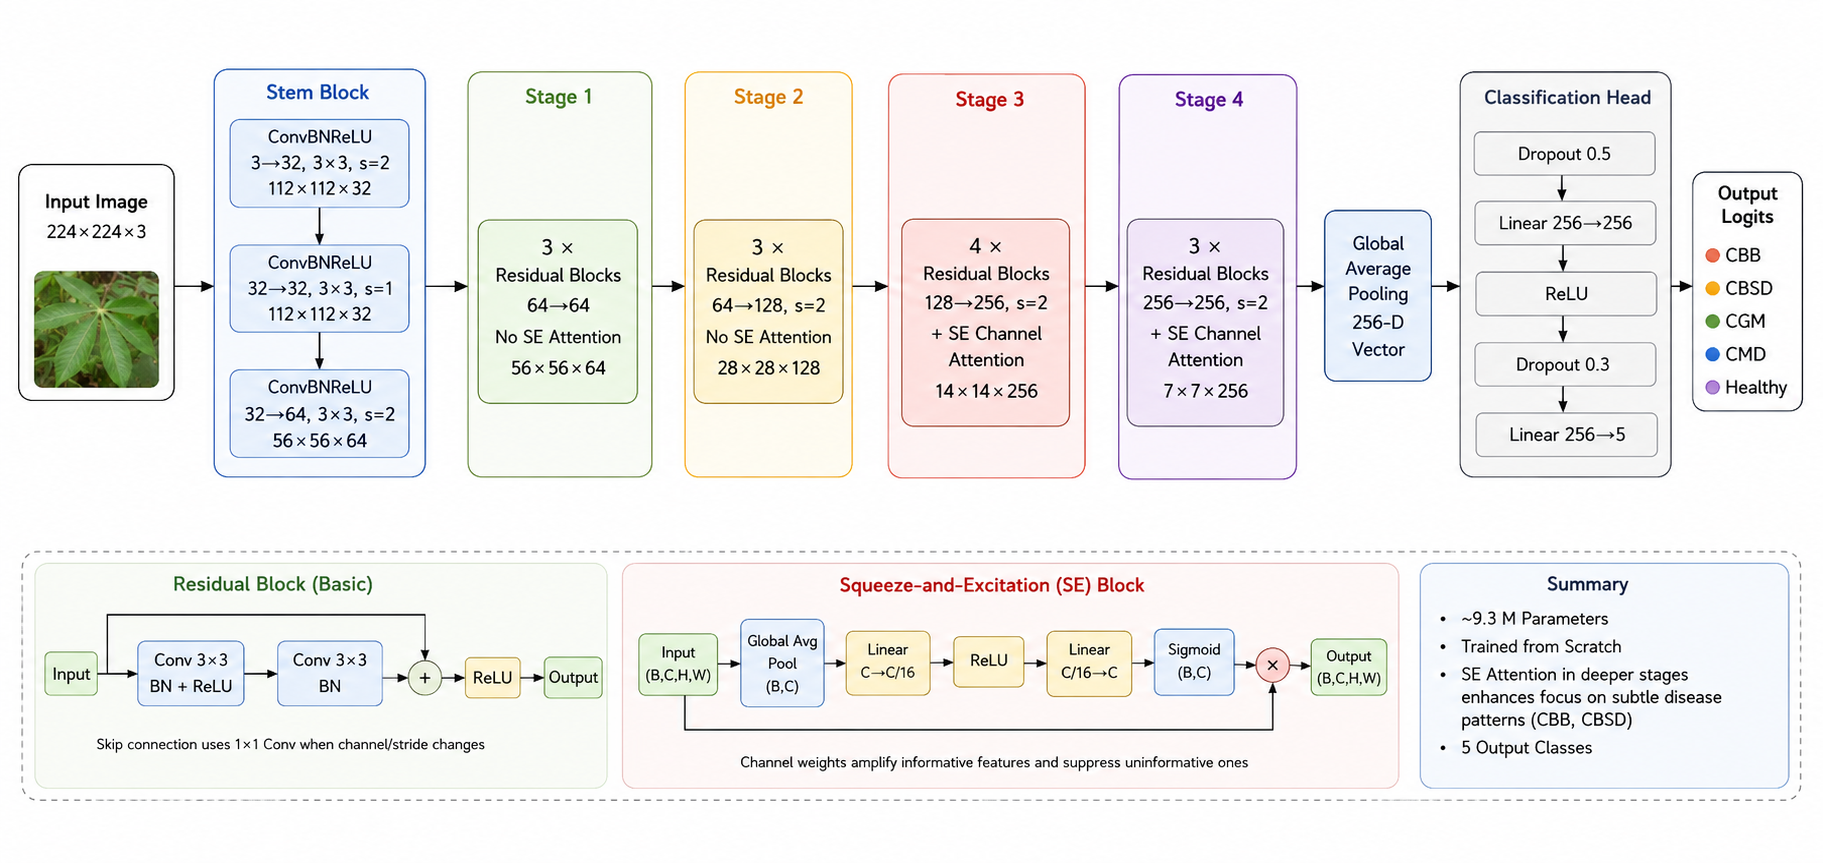


In [8]:
print('Model Architecture Summary')
print('=' * 55)
for arch in ['cassava_cnn', 'efficientnet_v2_s', 'swin_tiny']:
    info = build_model(arch, num_classes=NUM_CLASSES).model_info()
    print(f'{arch:25s}  total={info["total_params_M"]}M  '
          f'trainable={info["trainable_params_M"]}M  '
          f'frozen={info["frozen_params_M"]}M')

Model Architecture Summary
cassava_cnn                total=9.27M  trainable=9.27M  frozen=0.0M
efficientnet_v2_s          total=20.51M  trainable=0.33M  frozen=20.18M
swin_tiny                  total=27.93M  trainable=0.41M  frozen=27.52M


## 6. Training Strategies & Helper Functions

Each model is trained under two independent class-imbalance correction strategies and the better-performing one is kept:

| | Option A | Option B |
|---|---|---|
| **Loss** | FocalLoss (γ=2, α=None) | WeightedCE (label_smoothing=0.1) |
| **Sampling** | WeightedRandomSampler | Uniform shuffle |
| **Class weights in loss** | No — the sampler already up-samples minority classes | Yes — inverse-frequency weights penalise errors on rare classes more |
| **Regularisation** | Focal down-weighting of easy examples | Label smoothing discourages over-confident predictions |

Both options share the same two-phase schedule:
- **Phase 1** (5 epochs): backbone weights are locked; only the new classification head is updated at LR=1e-3 to stabilise it before any backbone gradients flow
- **Phase 2** (up to 30 epochs): all weights are released for end-to-end training at LR=1e-4, with early stopping triggered when val macro-F1 stops improving


In [9]:
def run_model_training(model_name, train_loader, val_loader, criterion, save_dir, warmup_epochs=5):
    model = build_model(model_name, num_classes=NUM_CLASSES).to(DEVICE)
    ckpt = Path(save_dir) / 'best_model.pth'

    if ckpt.exists():
        print(f'    Checkpoint found — loading {ckpt.name}')
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
        return model, None

    Path(save_dir).mkdir(parents=True, exist_ok=True)

    model.freeze_backbone()
    wu = Trainer(model, DEVICE, WARMUP_LR, WEIGHT_DECAY, criterion=criterion,
                 mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA)
    hist_wu = wu.train(train_loader, val_loader, warmup_epochs, 3, save_dir)

    model.unfreeze_backbone()
    ft = Trainer(model, DEVICE, LEARNING_RATE, WEIGHT_DECAY, criterion=criterion,
                 mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA)
    hist_ft = ft.train(train_loader, val_loader, NUM_EPOCHS, PATIENCE, save_dir)

    combined = {k: hist_wu[k] + hist_ft[k] for k in hist_wu}
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    return model, combined


def get_val_macro_f1(model, val_loader, cnames):
    ev = Evaluator(NUM_CLASSES, cnames, DEVICE)
    preds, labels = ev.predict(model, val_loader)
    return float(f1_score(labels, preds, average='macro', zero_division=0))


def select_and_save_best(model_name, f1a, f1b, dir_a, dir_b):
    if f1a >= f1b:
        src = Path(dir_a) / 'best_model.pth'
        winner = 'Option A (FocalLoss + WeightedRandomSampler)'
        best_f1 = f1a
    else:
        src = Path(dir_b) / 'best_model.pth'
        winner = 'Option B (WeightedCE + LabelSmoothing)'
        best_f1 = f1b
    dst = MODELS_DIR / f'{model_name}_best_model.pth'
    shutil.copy(str(src), str(dst))
    return winner, best_f1, dst


def draw_loss_curves(hist_a, hist_b, label_a, label_b, fig_title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, hist, title in [(axes[0], hist_a, label_a), (axes[1], hist_b, label_b)]:
        if hist is None:
            ax.text(0.5, 0.5, 'Loaded from checkpoint\n(no training history)', ha='center',
                    va='center', fontsize=11, transform=ax.transAxes)
            ax.set_title(title, fontsize=10)
            ax.axis('off')
            continue
        ep = range(1, len(hist['train_loss']) + 1)
        ax.plot(ep, hist['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
        ax.plot(ep, hist['val_loss'],   label='Val Loss',   color='coral',     linestyle='--', linewidth=2)
        ax_r = ax.twinx()
        ax_r.plot(ep, hist['val_macro_f1'], color='seagreen', linestyle=':', label='Val Macro-F1', linewidth=1.8)
        ax_r.set_ylabel('Val Macro-F1', color='seagreen', fontsize=9)
        ax_r.tick_params(axis='y', labelcolor='seagreen')
        best_ep = int(np.argmax(hist['val_macro_f1'])) + 1
        best_f1 = max(hist['val_macro_f1'])
        ax_r.axvline(best_ep, color='seagreen', linestyle=':', alpha=0.5)
        ax.set_title(f'{title}\nBest val macro-F1={best_f1:.4f} @ ep {best_ep}', fontsize=9)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(loc='upper left', fontsize=8)
        ax_r.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.suptitle(fig_title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    safe = fig_title.replace(' ', '_').replace('—', '').replace('/', '')
    plt.savefig(str(RESULTS_DIR / f'{safe}_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()


def compute_and_show_cm(model, test_loader, cnames, label):
    ev = Evaluator(NUM_CLASSES, cnames, DEVICE)
    preds, labels = ev.predict(model, test_loader)

    cm_raw  = confusion_matrix(labels, preds)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, mat, fmt, ttl in [
        (axes[0], cm_raw,  'd',    'Counts'),
        (axes[1], cm_norm, '.2f', 'Normalized'),
    ]:
        sns.heatmap(mat, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                    xticklabels=cnames, yticklabels=cnames, linewidths=0.4)
        ax.set_title(f'{label} — {ttl}', fontsize=11)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
        plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)

    plt.suptitle(f'Confusion Matrix: {label}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    safe = label.replace(' ', '_').replace('-', '')
    plt.savefig(str(RESULTS_DIR / f'{safe}_cm.png'), dpi=150, bbox_inches='tight')
    plt.show()

    macro_f1 = float(f1_score(labels, preds, average='macro', zero_division=0))
    met = ev.compute_metrics(labels, preds)

    print(f'\n{label} — Test Metrics')
    print(f'  Macro F1     : {macro_f1:.4f}')
    print(f'  Accuracy     : {met["accuracy"]:.4f}')
    print(f'  Precision    : {met["precision"]:.4f}')
    print(f'  Recall       : {met["recall"]:.4f}')
    print(f'  Weighted F1  : {met["f1"]:.4f}')
    print()
    f1_table = per_class_f1_report(list(labels), list(preds), NUM_CLASSES)
    display(f1_table)

    return np.array(labels), np.array(preds), met, macro_f1


print('Helper functions defined.')

Helper functions defined.


## 7. Model 1: CassavaCNN (Custom Residual Network)

Trained entirely from scratch with randomly initialised weights. Because there is no pretrained backbone to protect during warm-up, Phase 1 and Phase 2 differ only in learning rate — all layers are updated throughout both phases.


In [10]:
arch_cnn = 'cassava_cnn'

cw_train = compute_class_weights(split_df['train'], NUM_CLASSES)
best_model_ckpt = MODELS_DIR / f'{arch_cnn}_best_model.pth'

if best_model_ckpt.exists():
    print(f'Best checkpoint found — skipping training for {arch_cnn}.')
    print(f'  Loading: {best_model_ckpt}')
    cnn_best = build_model(arch_cnn, num_classes=NUM_CLASSES).to(DEVICE)
    cnn_best.load_state_dict(torch.load(best_model_ckpt, map_location=DEVICE, weights_only=True))
    cnn_best.eval()
    hist_cnn_a = hist_cnn_b = None
    f1_cnn_a = f1_cnn_b = get_val_macro_f1(cnn_best, loaders['val'], class_name_list)
    cnn_winner = 'Loaded from saved checkpoint'
    cnn_best_f1 = f1_cnn_a
    cnn_ckpt = best_model_ckpt
    print(f'  Val macro-F1 : {cnn_best_f1:.4f}')
else:
    print(f'Training: {arch_cnn}')
    print('=' * 60)

    sampler_cnn = build_weighted_sampler(split_df['train'], NUM_CLASSES)
    loader_cnn_a = DataLoader(
        CassavaDataset(split_df['train'], IMAGE_DIR, augment=True, image_size=INPUT_SIZE),
        sampler=sampler_cnn, **lkw
    )
    loader_cnn_b = DataLoader(
        CassavaDataset(split_df['train'], IMAGE_DIR, augment=True, image_size=INPUT_SIZE),
        shuffle=True, **lkw
    )

    crit_cnn_a = build_criterion('focal',       class_weights=None,      gamma=FOCAL_GAMMA).to(DEVICE)
    crit_cnn_b = build_criterion('weighted_ce', class_weights=cw_train,  label_smoothing=LABEL_SMOOTHING).to(DEVICE)

    dir_cnn_a = str(MODELS_DIR / arch_cnn / 'optA_focal_sampler')
    dir_cnn_b = str(MODELS_DIR / arch_cnn / 'optB_wce_smoothing')

    print('\nOption A — FocalLoss + WeightedRandomSampler')
    cnn_a, hist_cnn_a = run_model_training(arch_cnn, loader_cnn_a, loaders['val'], crit_cnn_a, dir_cnn_a)
    f1_cnn_a = get_val_macro_f1(cnn_a, loaders['val'], class_name_list)
    print(f'  val macro-F1 = {f1_cnn_a:.4f}')

    print('\nOption B — WeightedCE + LabelSmoothing')
    cnn_b, hist_cnn_b = run_model_training(arch_cnn, loader_cnn_b, loaders['val'], crit_cnn_b, dir_cnn_b)
    f1_cnn_b = get_val_macro_f1(cnn_b, loaders['val'], class_name_list)
    print(f'  val macro-F1 = {f1_cnn_b:.4f}')

    print('\n--- Strategy Selection ---')
    cnn_winner, cnn_best_f1, cnn_ckpt = select_and_save_best(arch_cnn, f1_cnn_a, f1_cnn_b, dir_cnn_a, dir_cnn_b)
    cnn_best = cnn_a if f1_cnn_a >= f1_cnn_b else cnn_b

    print(f'\nWinner  : {cnn_winner}')
    print(f'Val F1  : {cnn_best_f1:.4f}')
    print(f'Saved   : {cnn_ckpt}')


Training: cassava_cnn

Option A — FocalLoss + WeightedRandomSampler
Epoch   1/5 | Train loss 0.9232  acc 0.3010 | Val loss 0.7059  acc 0.6175  macro-F1 0.2368 | LR 9.05e-04
  ✓ Best model saved (macro-F1=0.2368) → /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/models/cassava_cnn/optA_focal_sampler/best_model.pth
Epoch   2/5 | Train loss 0.8458  acc 0.3434 | Val loss 1.0254  acc 0.2293  macro-F1 0.1538 | LR 6.55e-04
Epoch   3/5 | Train loss 0.8228  acc 0.3691 | Val loss 0.7207  acc 0.5658  macro-F1 0.2839 | LR 3.46e-04
  ✓ Best model saved (macro-F1=0.2839) → /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/models/cassava_cnn/optA_focal_sampler/best_model.pth
Epoch   4/5 | Train loss 0.7854  acc 0.4029 | Val loss 0.6715  acc 0.6292  macro-F1 0.2900 | LR 9.64e-05
  ✓ Best model saved (macro-F1=0.2900) → /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/models/cassava_cnn/optA_f

,Option,Val Macro-F1,Winner
0,A — FocalLoss + Sampler,0.3228,YES
1,B — WeightedCE + Smoothing,0.2837,


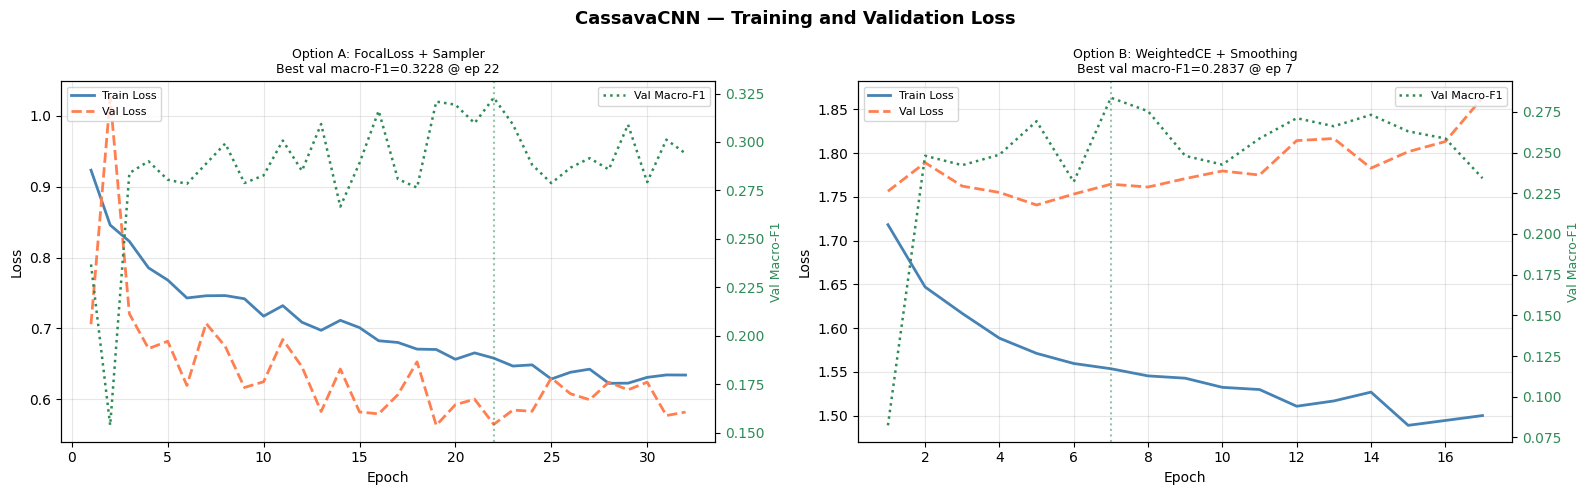

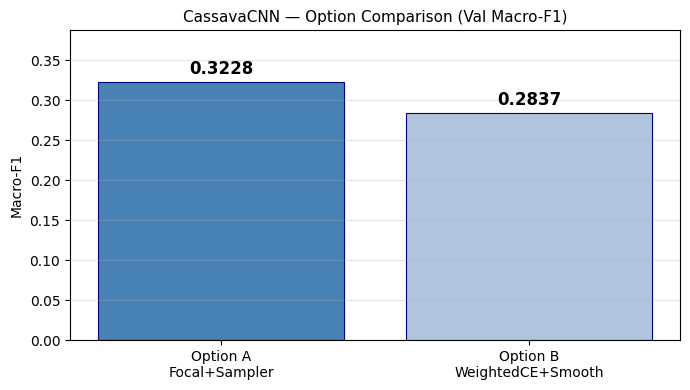

In [11]:
draw_loss_curves(
    hist_cnn_a, hist_cnn_b,
    'Option A: FocalLoss + Sampler',
    'Option B: WeightedCE + Smoothing',
    'CassavaCNN — Training and Validation Loss'
)

fig, ax = plt.subplots(figsize=(7, 4))
bar_labels = ['Option A\nFocal+Sampler', 'Option B\nWeightedCE+Smooth']
bar_vals   = [f1_cnn_a, f1_cnn_b]
bar_colors = ['steelblue' if v == max(bar_vals) else 'lightsteelblue' for v in bar_vals]
bars = ax.bar(bar_labels, bar_vals, color=bar_colors, edgecolor='navy', linewidth=0.8)
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f'{val:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('CassavaCNN — Option Comparison (Val Macro-F1)', fontsize=11)
ax.set_ylabel('Macro-F1')
ax.set_ylim(0, max(bar_vals) * 1.2)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

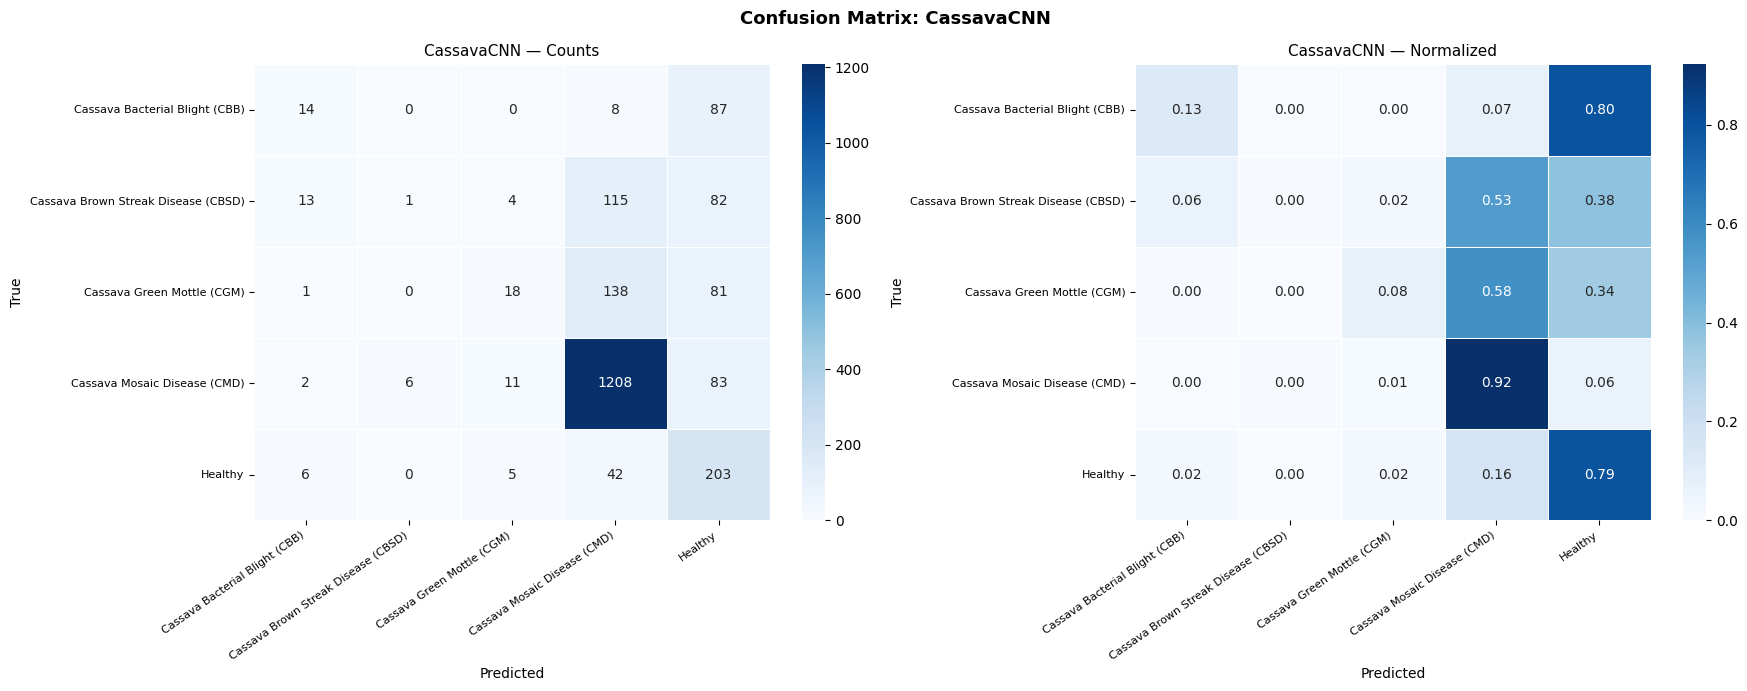


CassavaCNN — Test Metrics
  Macro F1     : 0.3403
  Accuracy     : 0.6786
  Precision    : 0.6250
  Recall       : 0.6786
  Weighted F1  : 0.6143



,class,precision,recall,f1,support
0,Cassava Bacterial Blight (CBB),0.389,0.128,0.193,109
1,Cassava Brown Streak Disease (CBSD),0.143,0.005,0.009,215
2,Cassava Green Mottle (CGM),0.474,0.076,0.130,238
3,Cassava Mosaic Disease (CMD),0.799,0.922,0.856,1310
4,Healthy,0.379,0.793,0.513,256


In [12]:
labels_cnn, preds_cnn, met_cnn, macro_f1_cnn = compute_and_show_cm(
    cnn_best, loaders['test'], class_name_list, 'CassavaCNN'
)

## 8. Model 2: EfficientNet-V2-S (Pretrained Transfer Learning)

Initialised with ImageNet-1K weights. Phase 1 locks the backbone and warms up only the new disease-classification head. Once the head is stable, Phase 2 releases all layers for full end-to-end fine-tuning.


In [13]:
arch_eff = 'efficientnet_v2_s'
best_model_ckpt = MODELS_DIR / f'{arch_eff}_best_model.pth'

if best_model_ckpt.exists():
    print(f'Best checkpoint found — skipping training for {arch_eff}.')
    print(f'  Loading: {best_model_ckpt}')
    eff_best = build_model(arch_eff, num_classes=NUM_CLASSES).to(DEVICE)
    eff_best.load_state_dict(torch.load(best_model_ckpt, map_location=DEVICE, weights_only=True))
    eff_best.eval()
    hist_eff_a = hist_eff_b = None
    f1_eff_a = f1_eff_b = get_val_macro_f1(eff_best, loaders['val'], class_name_list)
    eff_winner = 'Loaded from saved checkpoint'
    eff_best_f1 = f1_eff_a
    eff_ckpt = best_model_ckpt
    print(f'  Val macro-F1 : {eff_best_f1:.4f}')
else:
    print(f'Training: {arch_eff}')
    print('=' * 60)

    sampler_eff = build_weighted_sampler(split_df['train'], NUM_CLASSES)
    loader_eff_a = DataLoader(
        CassavaDataset(split_df['train'], IMAGE_DIR, augment=True, image_size=INPUT_SIZE),
        sampler=sampler_eff, **lkw
    )
    loader_eff_b = DataLoader(
        CassavaDataset(split_df['train'], IMAGE_DIR, augment=True, image_size=INPUT_SIZE),
        shuffle=True, **lkw
    )

    crit_eff_a = build_criterion('focal',       class_weights=None,     gamma=FOCAL_GAMMA).to(DEVICE)
    crit_eff_b = build_criterion('weighted_ce', class_weights=cw_train, label_smoothing=LABEL_SMOOTHING).to(DEVICE)

    dir_eff_a = str(MODELS_DIR / arch_eff / 'optA_focal_sampler')
    dir_eff_b = str(MODELS_DIR / arch_eff / 'optB_wce_smoothing')

    print('\nOption A — FocalLoss + WeightedRandomSampler')
    eff_a, hist_eff_a = run_model_training(arch_eff, loader_eff_a, loaders['val'], crit_eff_a, dir_eff_a)
    f1_eff_a = get_val_macro_f1(eff_a, loaders['val'], class_name_list)
    print(f'  val macro-F1 = {f1_eff_a:.4f}')

    print('\nOption B — WeightedCE + LabelSmoothing')
    eff_b, hist_eff_b = run_model_training(arch_eff, loader_eff_b, loaders['val'], crit_eff_b, dir_eff_b)
    f1_eff_b = get_val_macro_f1(eff_b, loaders['val'], class_name_list)
    print(f'  val macro-F1 = {f1_eff_b:.4f}')

    print('\n--- Strategy Selection ---')
    eff_winner, eff_best_f1, eff_ckpt = select_and_save_best(arch_eff, f1_eff_a, f1_eff_b, dir_eff_a, dir_eff_b)
    eff_best = eff_a if f1_eff_a >= f1_eff_b else eff_b

    print(f'\nWinner  : {eff_winner}')
    print(f'Val F1  : {eff_best_f1:.4f}')
    print(f'Saved   : {eff_ckpt}')


Training: efficientnet_v2_s

Option A — FocalLoss + WeightedRandomSampler
Epoch   1/5 | Train loss 0.8484  acc 0.4013 | Val loss 0.6277  acc 0.6076  macro-F1 0.3815 | LR 9.05e-04
  ✓ Best model saved (macro-F1=0.3815) → /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/models/efficientnet_v2_s/optA_focal_sampler/best_model.pth
Epoch   2/5 | Train loss 0.8006  acc 0.4323 | Val loss 0.6289  acc 0.5639  macro-F1 0.3262 | LR 6.55e-04
Epoch   3/5 | Train loss 0.7900  acc 0.4432 | Val loss 0.5778  acc 0.6133  macro-F1 0.3435 | LR 3.46e-04
Epoch   4/5 | Train loss 0.7795  acc 0.4513 | Val loss 0.5805  acc 0.6090  macro-F1 0.3410 | LR 9.64e-05

Early stopping at epoch 4 — no macro-F1 gain for 3 epochs.

Training finished in 15.8 min.
Epoch   1/30 | Train loss 0.6129  acc 0.5680 | Val loss 0.4797  acc 0.7072  macro-F1 0.4051 | LR 9.97e-05
  ✓ Best model saved (macro-F1=0.4051) → /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vi

,Option,Val Macro-F1,Winner
0,A — FocalLoss + Sampler,0.6419,YES
1,B — WeightedCE + Smoothing,0.6390,


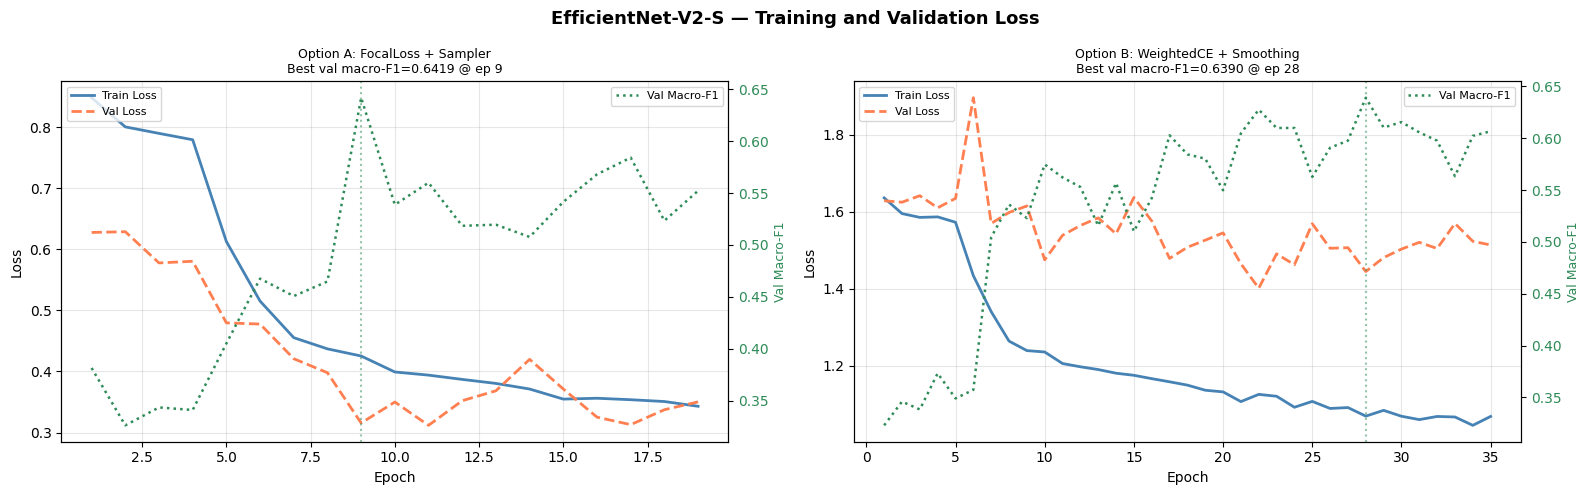

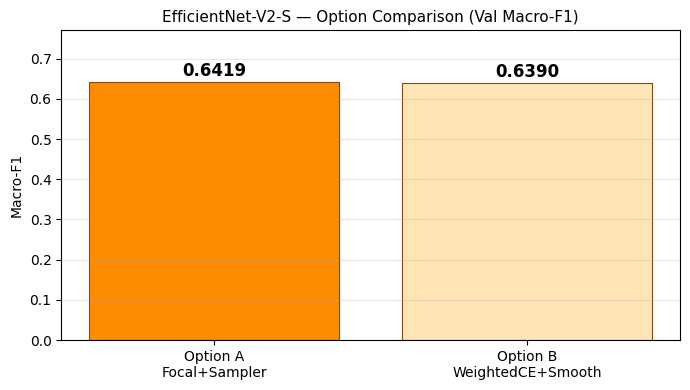

In [14]:
draw_loss_curves(
    hist_eff_a, hist_eff_b,
    'Option A: FocalLoss + Sampler',
    'Option B: WeightedCE + Smoothing',
    'EfficientNet-V2-S — Training and Validation Loss'
)

fig, ax = plt.subplots(figsize=(7, 4))
bar_vals   = [f1_eff_a, f1_eff_b]
bar_colors = ['darkorange' if v == max(bar_vals) else 'moccasin' for v in bar_vals]
bars = ax.bar(['Option A\nFocal+Sampler', 'Option B\nWeightedCE+Smooth'],
               bar_vals, color=bar_colors, edgecolor='saddlebrown', linewidth=0.8)
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f'{val:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('EfficientNet-V2-S — Option Comparison (Val Macro-F1)', fontsize=11)
ax.set_ylabel('Macro-F1')
ax.set_ylim(0, max(bar_vals) * 1.2)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

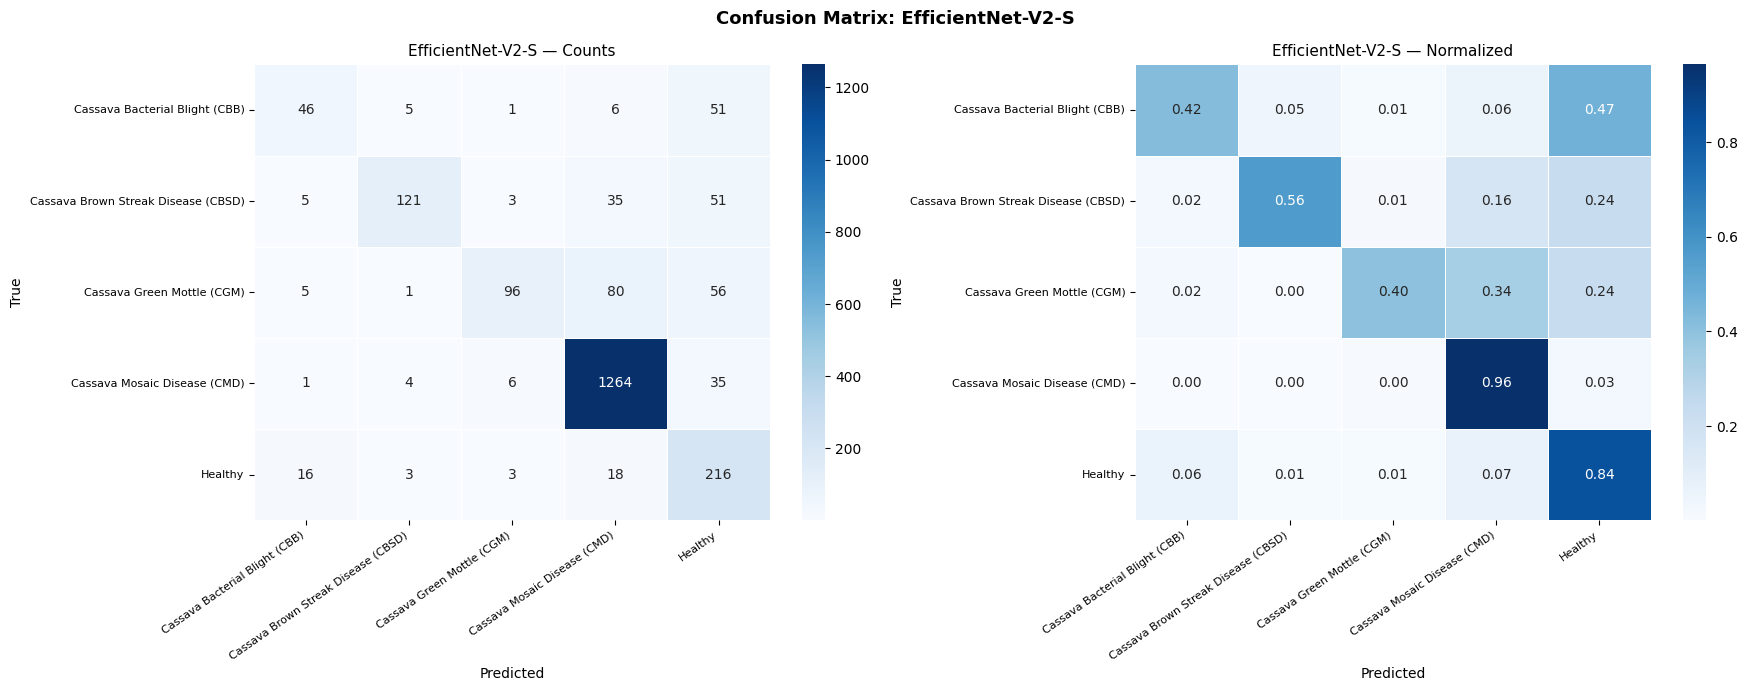


EfficientNet-V2-S — Test Metrics
  Macro F1     : 0.6667
  Accuracy     : 0.8191
  Precision    : 0.8402
  Recall       : 0.8191
  Weighted F1  : 0.8096



,class,precision,recall,f1,support
0,Cassava Bacterial Blight (CBB),0.630,0.422,0.505,109
1,Cassava Brown Streak Disease (CBSD),0.903,0.563,0.693,215
2,Cassava Green Mottle (CGM),0.881,0.403,0.553,238
3,Cassava Mosaic Disease (CMD),0.901,0.965,0.932,1310
4,Healthy,0.528,0.844,0.650,256


In [15]:
labels_eff, preds_eff, met_eff, macro_f1_eff = compute_and_show_cm(
    eff_best, loaders['test'], class_name_list, 'EfficientNet-V2-S'
)

## 9. Model 3: Swin-Tiny + LoRA (Vision Transformer)

Swin-Tiny is adapted with LoRA (Low-Rank Adaptation): rank-8 matrix pairs (B·A, each much smaller than the original weight matrix) are inserted into the self-attention projection layers. This keeps the pretrained weights frozen and only trains the low-rank additions (~0.5 M params) plus the head during Phase 1. Phase 2 removes all locks so the entire network can fine-tune together.


In [16]:
arch_swin = 'swin_tiny'
best_model_ckpt = MODELS_DIR / f'{arch_swin}_best_model.pth'

if best_model_ckpt.exists():
    print(f'Best checkpoint found — skipping training for {arch_swin}.')
    print(f'  Loading: {best_model_ckpt}')
    swin_best = build_model(arch_swin, num_classes=NUM_CLASSES).to(DEVICE)
    swin_best.load_state_dict(torch.load(best_model_ckpt, map_location=DEVICE, weights_only=True))
    swin_best.eval()
    hist_swin_a = hist_swin_b = None
    f1_swin_a = f1_swin_b = get_val_macro_f1(swin_best, loaders['val'], class_name_list)
    swin_winner = 'Loaded from saved checkpoint'
    swin_best_f1 = f1_swin_a
    swin_ckpt = best_model_ckpt
    print(f'  Val macro-F1 : {swin_best_f1:.4f}')
else:
    print(f'Training: {arch_swin}')
    print('=' * 60)

    sampler_swin = build_weighted_sampler(split_df['train'], NUM_CLASSES)
    loader_swin_a = DataLoader(
        CassavaDataset(split_df['train'], IMAGE_DIR, augment=True, image_size=INPUT_SIZE),
        sampler=sampler_swin, **lkw
    )
    loader_swin_b = DataLoader(
        CassavaDataset(split_df['train'], IMAGE_DIR, augment=True, image_size=INPUT_SIZE),
        shuffle=True, **lkw
    )

    crit_swin_a = build_criterion('focal',       class_weights=None,     gamma=FOCAL_GAMMA).to(DEVICE)
    crit_swin_b = build_criterion('weighted_ce', class_weights=cw_train, label_smoothing=LABEL_SMOOTHING).to(DEVICE)

    dir_swin_a = str(MODELS_DIR / arch_swin / 'optA_focal_sampler')
    dir_swin_b = str(MODELS_DIR / arch_swin / 'optB_wce_smoothing')

    print('\nOption A — FocalLoss + WeightedRandomSampler')
    swin_a, hist_swin_a = run_model_training(arch_swin, loader_swin_a, loaders['val'], crit_swin_a, dir_swin_a)
    f1_swin_a = get_val_macro_f1(swin_a, loaders['val'], class_name_list)
    print(f'  val macro-F1 = {f1_swin_a:.4f}')

    print('\nOption B — WeightedCE + LabelSmoothing')
    swin_b, hist_swin_b = run_model_training(arch_swin, loader_swin_b, loaders['val'], crit_swin_b, dir_swin_b)
    f1_swin_b = get_val_macro_f1(swin_b, loaders['val'], class_name_list)
    print(f'  val macro-F1 = {f1_swin_b:.4f}')

    print('\n--- Strategy Selection ---')
    swin_winner, swin_best_f1, swin_ckpt = select_and_save_best(arch_swin, f1_swin_a, f1_swin_b, dir_swin_a, dir_swin_b)
    swin_best = swin_a if f1_swin_a >= f1_swin_b else swin_b

    print(f'\nWinner  : {swin_winner}')
    print(f'Val F1  : {swin_best_f1:.4f}')
    print(f'Saved   : {swin_ckpt}')


Training: swin_tiny

Option A — FocalLoss + WeightedRandomSampler
Epoch   1/5 | Train loss 0.6373  acc 0.5364 | Val loss 0.5268  acc 0.7152  macro-F1 0.3855 | LR 9.05e-04
  ✓ Best model saved (macro-F1=0.3855) → /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/models/swin_tiny/optA_focal_sampler/best_model.pth
Epoch   2/5 | Train loss 0.5184  acc 0.6193 | Val loss 0.3293  acc 0.7716  macro-F1 0.5717 | LR 6.55e-04
  ✓ Best model saved (macro-F1=0.5717) → /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/models/swin_tiny/optA_focal_sampler/best_model.pth
Epoch   3/5 | Train loss 0.4882  acc 0.6427 | Val loss 0.3686  acc 0.7730  macro-F1 0.5502 | LR 3.46e-04
Epoch   4/5 | Train loss 0.4432  acc 0.6632 | Val loss 0.3550  acc 0.7716  macro-F1 0.5393 | LR 9.64e-05
Epoch   5/5 | Train loss 0.4391  acc 0.6672 | Val loss 0.4018  acc 0.7580  macro-F1 0.5134 | LR 1.00e-06

Early stopping at epoch 5 — no macro-F1 gain for 3 e

,Option,Val Macro-F1,Winner
0,A — FocalLoss + Sampler,0.6062,
1,B — WeightedCE + Smoothing,0.6266,YES


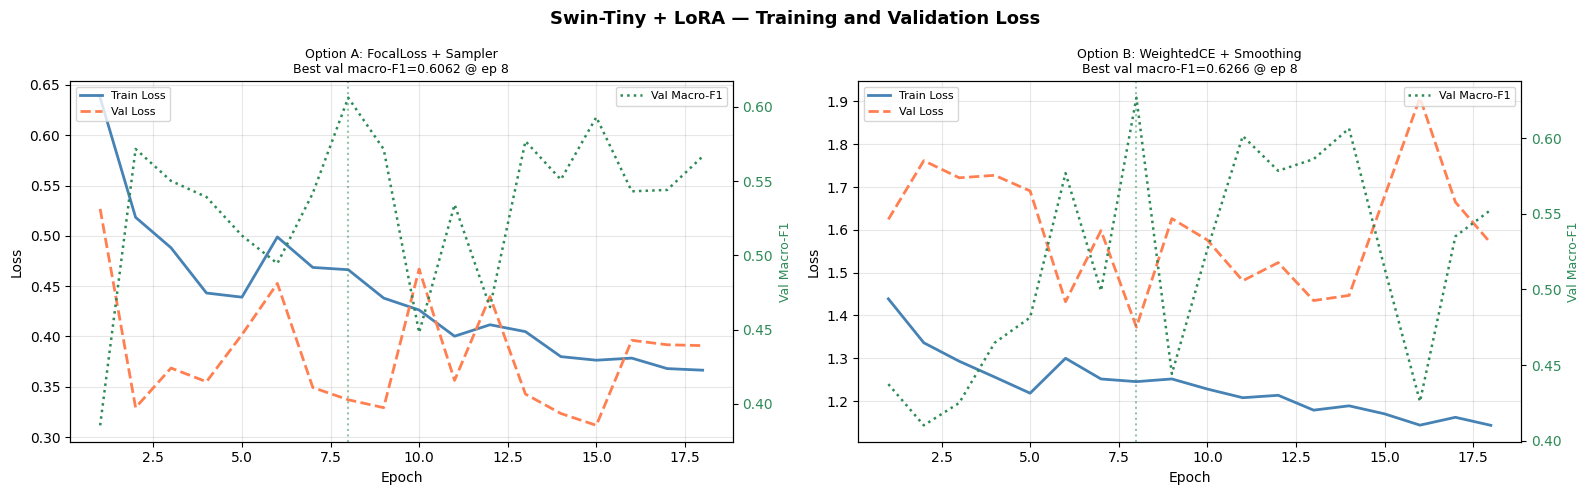

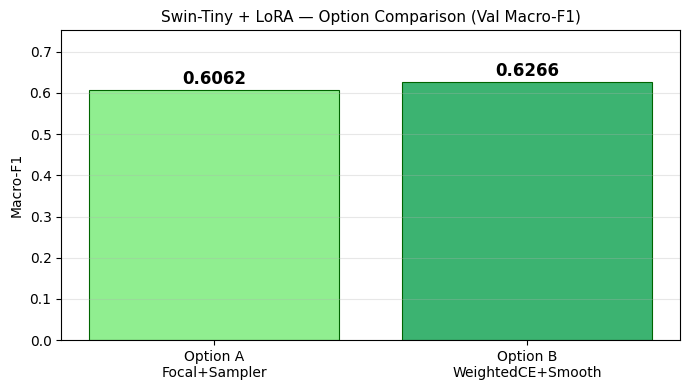

In [17]:
draw_loss_curves(
    hist_swin_a, hist_swin_b,
    'Option A: FocalLoss + Sampler',
    'Option B: WeightedCE + Smoothing',
    'Swin-Tiny + LoRA — Training and Validation Loss'
)

fig, ax = plt.subplots(figsize=(7, 4))
bar_vals   = [f1_swin_a, f1_swin_b]
bar_colors = ['mediumseagreen' if v == max(bar_vals) else 'lightgreen' for v in bar_vals]
bars = ax.bar(['Option A\nFocal+Sampler', 'Option B\nWeightedCE+Smooth'],
               bar_vals, color=bar_colors, edgecolor='darkgreen', linewidth=0.8)
for bar, val in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f'{val:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Swin-Tiny + LoRA — Option Comparison (Val Macro-F1)', fontsize=11)
ax.set_ylabel('Macro-F1')
ax.set_ylim(0, max(bar_vals) * 1.2)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

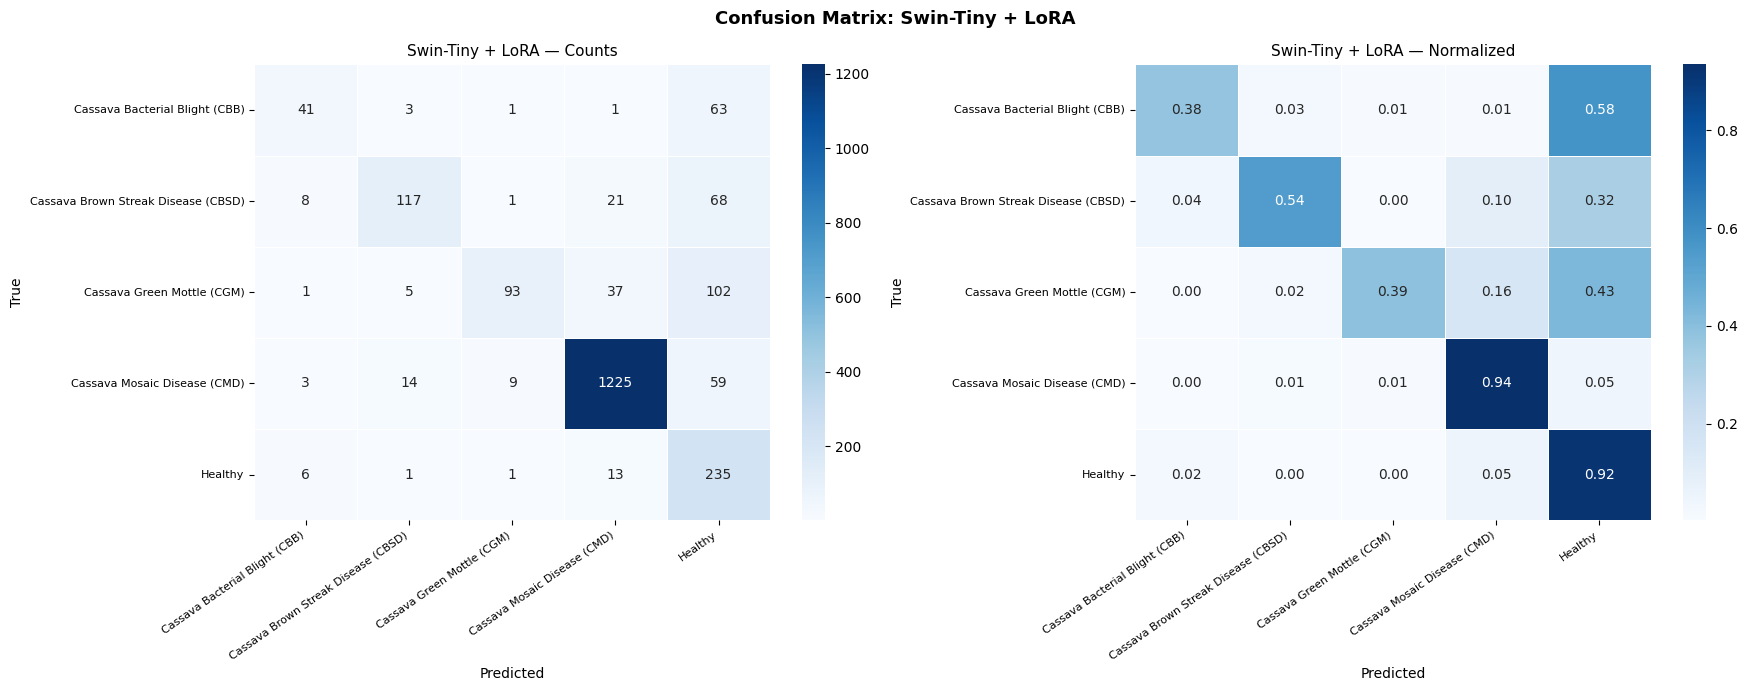


Swin-Tiny + LoRA — Test Metrics
  Macro F1     : 0.6459
  Accuracy     : 0.8040
  Precision    : 0.8542
  Recall       : 0.8040
  Weighted F1  : 0.8030



,class,precision,recall,f1,support
0,Cassava Bacterial Blight (CBB),0.695,0.376,0.488,109
1,Cassava Brown Streak Disease (CBSD),0.836,0.544,0.659,215
2,Cassava Green Mottle (CGM),0.886,0.391,0.542,238
3,Cassava Mosaic Disease (CMD),0.944,0.935,0.940,1310
4,Healthy,0.446,0.918,0.600,256


In [18]:
labels_swin, preds_swin, met_swin, macro_f1_swin = compute_and_show_cm(
    swin_best, loaders['test'], class_name_list, 'Swin-Tiny + LoRA'
)

## 10. Final Model Comparison

The best-checkpoint from every model is loaded and scored against the same held-out test split. Macro-F1 is the deciding metric: it averages each class's individual F1 score without weighting by class size, so a rare disease like CBB (5.1% of images) contributes just as much to the final score as the dominant CMD class (61.5%). This makes it a more honest measure of real-world usefulness than overall accuracy.


In [19]:
print('Loading saved best-model checkpoints...')

all_models = {}
all_results = {}

arch_labels = {
    'cassava_cnn':       'CassavaCNN',
    'efficientnet_v2_s': 'EfficientNet-V2-S',
    'swin_tiny':         'Swin-Tiny + LoRA',
}

for nm, label in arch_labels.items():
    ckpt = MODELS_DIR / f'{nm}_best_model.pth'
    if not ckpt.exists():
        print(f'  WARNING: {ckpt} not found — skipping.')
        continue

    m = build_model(nm, num_classes=NUM_CLASSES).to(DEVICE)
    m.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    m.eval()
    all_models[nm] = m

    ev = Evaluator(NUM_CLASSES, class_name_list, DEVICE)
    preds, labels = ev.predict(m, loaders['test'])
    met = ev.compute_metrics(labels, preds)
    macro = float(f1_score(labels, preds, average='macro', zero_division=0))
    info  = build_model(nm, NUM_CLASSES).model_info()

    all_results[nm] = {
        'label':        label,
        'macro_f1':     round(macro, 4),
        'accuracy':     round(float(met['accuracy']),  4),
        'weighted_f1':  round(float(met['f1']),        4),
        'precision':    round(float(met['precision']), 4),
        'recall':       round(float(met['recall']),    4),
        'params_M':     info['total_params_M'],
        'preds':        preds,
        'labels':       labels,
    }
    print(f'  {label:25s}  macro_f1={macro:.4f}  accuracy={met["accuracy"]:.4f}  params={info["total_params_M"]}M')

Loading saved best-model checkpoints...
  CassavaCNN                 macro_f1=0.3403  accuracy=0.6786  params=9.27M
  EfficientNet-V2-S          macro_f1=0.6667  accuracy=0.8191  params=20.51M
  Swin-Tiny + LoRA           macro_f1=0.6459  accuracy=0.8040  params=27.93M


,Model,Macro F1,Accuracy,Weighted F1,Precision,Recall,Params (M)
1,EfficientNet-V2-S,0.6667,0.8191,0.8096,0.8402,0.8191,20.51
2,Swin-Tiny + LoRA,0.6459,0.8040,0.8030,0.8542,0.8040,27.93
3,CassavaCNN,0.3403,0.6786,0.6143,0.6250,0.6786,9.27



Saved comparison table to: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/results/final_model_comparison.json


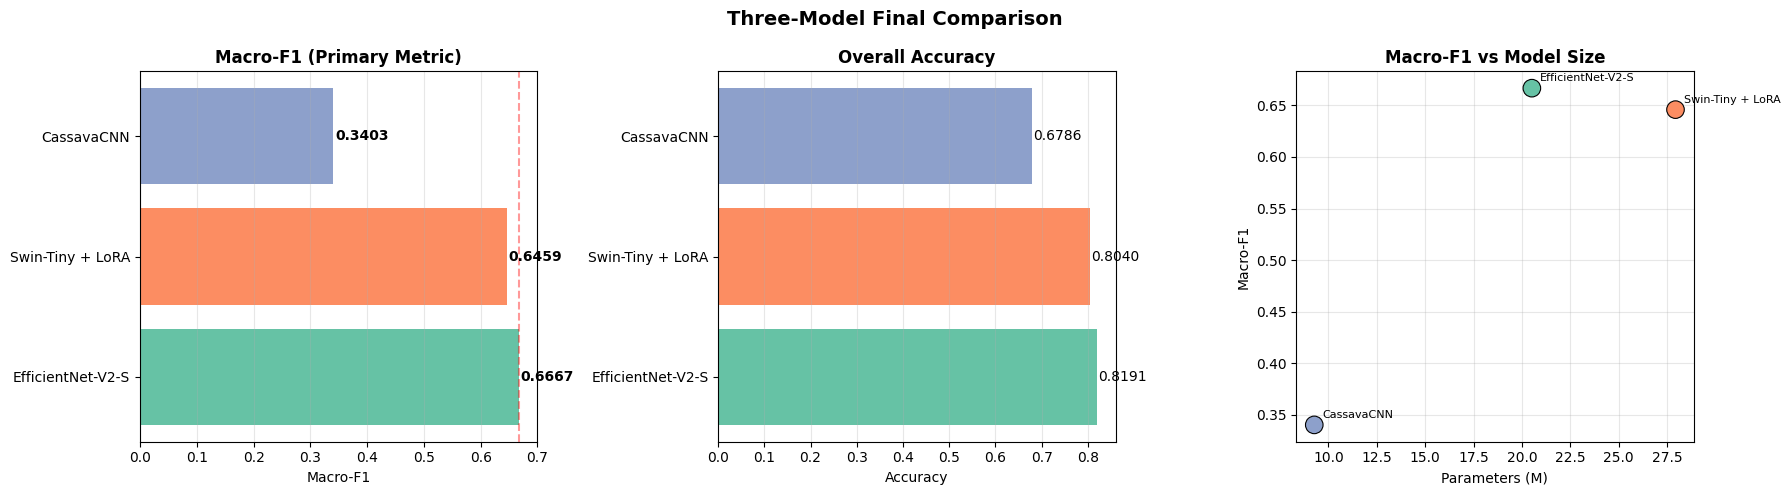

In [20]:
rows = []
for nm, r in all_results.items():
    rows.append({
        'Model':        r['label'],
        'Macro F1':     r['macro_f1'],
        'Accuracy':     r['accuracy'],
        'Weighted F1':  r['weighted_f1'],
        'Precision':    r['precision'],
        'Recall':       r['recall'],
        'Params (M)':   r['params_M'],
    })

comp_df = pd.DataFrame(rows).sort_values('Macro F1', ascending=False).reset_index(drop=True)
comp_df.index += 1
display(comp_df)

comp_df.to_json(str(RESULTS_DIR / 'final_model_comparison.json'), orient='records', indent=4)
print(f'\nSaved comparison table to: {RESULTS_DIR / "final_model_comparison.json"}')

model_labels = comp_df['Model'].tolist()
palette_bar  = sns.color_palette('Set2', len(comp_df))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bars0 = axes[0].barh(model_labels, comp_df['Macro F1'], color=palette_bar)
axes[0].set_xlabel('Macro-F1')
axes[0].set_title('Macro-F1 (Primary Metric)', fontweight='bold')
axes[0].axvline(comp_df['Macro F1'].max(), color='red', linestyle='--', alpha=0.4)
for bar, val in zip(bars0, comp_df['Macro F1']):
    axes[0].text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

bars1 = axes[1].barh(model_labels, comp_df['Accuracy'], color=palette_bar)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('Overall Accuracy', fontweight='bold')
for bar, val in zip(bars1, comp_df['Accuracy']):
    axes[1].text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='x')

axes[2].scatter(comp_df['Params (M)'], comp_df['Macro F1'], s=160,
                color=palette_bar, zorder=4, edgecolors='black', linewidths=0.8)
for _, row in comp_df.iterrows():
    axes[2].annotate(row['Model'], (row['Params (M)'], row['Macro F1']),
                     textcoords='offset points', xytext=(6, 5), fontsize=8)
axes[2].set_xlabel('Parameters (M)')
axes[2].set_ylabel('Macro-F1')
axes[2].set_title('Macro-F1 vs Model Size', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Three-Model Final Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'final_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

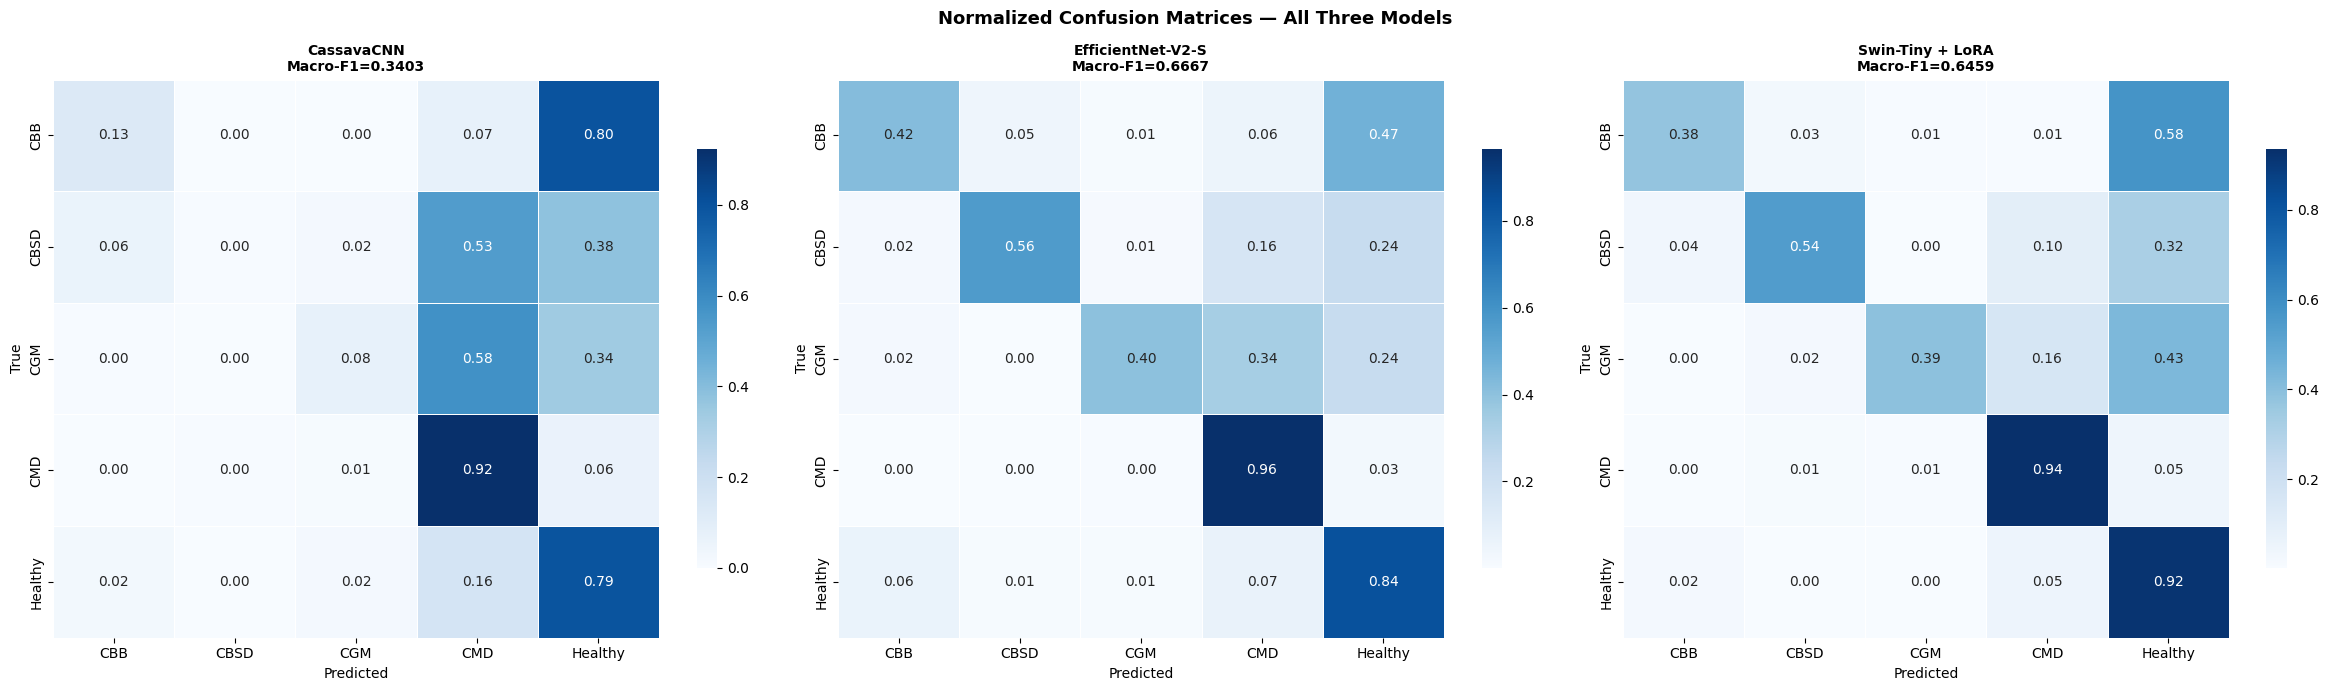

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (nm, r) in zip(axes, all_results.items()):
    cm_norm = confusion_matrix(r['labels'], r['preds']).astype(float)
    cm_norm = cm_norm / cm_norm.sum(axis=1, keepdims=True)
    short_names = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=short_names, yticklabels=short_names,
                linewidths=0.4, cbar_kws={'shrink': 0.75})
    ax.set_title(f'{r["label"]}\nMacro-F1={r["macro_f1"]:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Normalized Confusion Matrices — All Three Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'all_models_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

In [22]:
best_nm  = comp_df.iloc[0]['Model']
best_row = comp_df.iloc[0]

print('=' * 70)
print('RECOMMENDATION')
print('=' * 70)
print(f'  Best model     : {best_nm}')
print(f'  Macro-F1       : {best_row["Macro F1"]:.4f}  (primary metric for imbalanced data)')
print(f'  Accuracy       : {best_row["Accuracy"]:.4f}')
print(f'  Weighted F1    : {best_row["Weighted F1"]:.4f}')
print(f'  Parameters     : {best_row["Params (M)"]} M')
print()

per_class_rows = []
best_key = [k for k, v in all_results.items() if v['label'] == best_nm][0]
best_res = all_results[best_key]
f1_table_best = per_class_f1_report(list(best_res['labels']), list(best_res['preds']), NUM_CLASSES)
print('Per-class F1 (best model):')
display(f1_table_best)

print()
print('Ranking by Macro-F1:')
for rank, row in comp_df.iterrows():
    indicator = '<-- BEST' if rank == 1 else ''
    print(f'  {rank}. {row["Model"]:25s}  macro-F1={row["Macro F1"]:.4f}  {indicator}')
print('=' * 70)


RECOMMENDATION
  Best model     : EfficientNet-V2-S
  Macro-F1       : 0.6667  (primary metric for imbalanced data)
  Accuracy       : 0.8191
  Weighted F1    : 0.8096
  Parameters     : 20.51 M

Per-class F1 (best model):


,class,precision,recall,f1,support
0,Cassava Bacterial Blight (CBB),0.630,0.422,0.505,109
1,Cassava Brown Streak Disease (CBSD),0.903,0.563,0.693,215
2,Cassava Green Mottle (CGM),0.881,0.403,0.553,238
3,Cassava Mosaic Disease (CMD),0.901,0.965,0.932,1310
4,Healthy,0.528,0.844,0.650,256



Ranking by Macro-F1:
  1. EfficientNet-V2-S          macro-F1=0.6667  <-- BEST
  2. Swin-Tiny + LoRA           macro-F1=0.6459  
  3. CassavaCNN                 macro-F1=0.3403  

Decision rationale:
  Macro-F1 is used as the primary ranking metric because the cassava
  dataset is severely imbalanced (CMD 61.5%, CBB 5.1%). Accuracy alone
  would reward models that predict CMD for every input. Macro-F1 gives
  equal weight to each class, ensuring minority diseases are not ignored.


## 11. Grad-CAM Explainability

To check that the best model is learning the right visual cues, Grad-CAM heatmaps are generated for a sample of test images. Grad-CAM works by computing the gradient of the predicted class score with respect to the last convolutional feature map; those gradients are averaged per channel and used to linearly combine the feature maps into a single spatial importance map. For a cassava disease classifier, the resulting heatmap should light up over symptomatic leaf regions — mosaic patterns, necrotic spots, yellowing streaks — not over background soil or sky. Cases where the activation lands in the wrong area flag potential failure modes even when the prediction happens to be correct.


Grad-CAM using: EfficientNet-V2-S (efficientnet_v2_s)


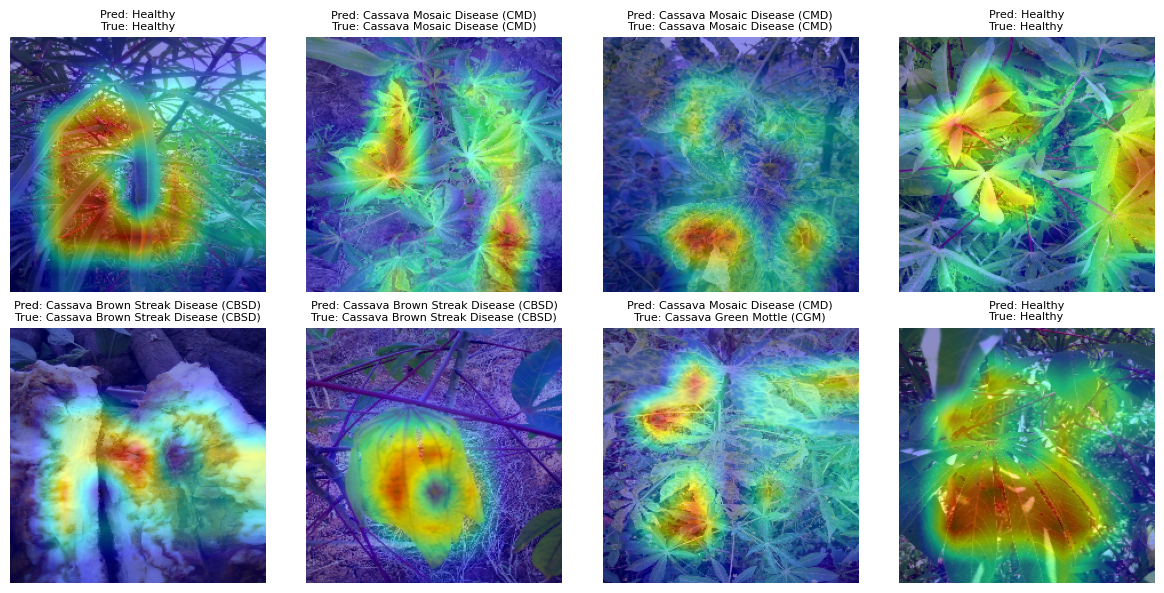

In [23]:
best_arch = [k for k, v in all_results.items() if v['label'] == best_nm][0]
best_model_vis = all_models[best_arch]

print(f'Grad-CAM using: {best_nm} ({best_arch})')

rng = np.random.RandomState(SEED)
sample_indices = rng.choice(len(split_df['test']), size=8, replace=False)

sample_images, sample_true_labels = [], []
for idx in sample_indices:
    row = split_df['test'].iloc[idx]
    img = cv2.imread(str(IMAGE_DIR / row['image_id']))
    if img is not None:
        sample_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        sample_true_labels.append(int(row['label']))

show_gradcam_grid(
    model       = best_model_vis,
    model_name  = best_arch,
    images      = sample_images,
    image_size  = INPUT_SIZE,
    class_names = disease_names,
    device      = DEVICE,
    true_labels = sample_true_labels,
    cols        = 4,
)

## 12. Error Analysis

### Focused Error Analysis
A random selection of misclassified test images is displayed alongside their Grad-CAM overlays. This lets us judge whether wrong predictions come from genuinely ambiguous leaf presentations (where even a human might hesitate) or from the model attending to irrelevant parts of the image.

### In-Depth Error Analysis
The full confusion matrix is decomposed to find which class pairs are most frequently mixed up, and per-class recall is examined to pinpoint where the model is systematically weakest.


Misclassified: 385 / 2,128 (18.1%)
Correctly classified: 1,743 (81.9%)

Grad-CAM overlays for 8 misclassified samples:


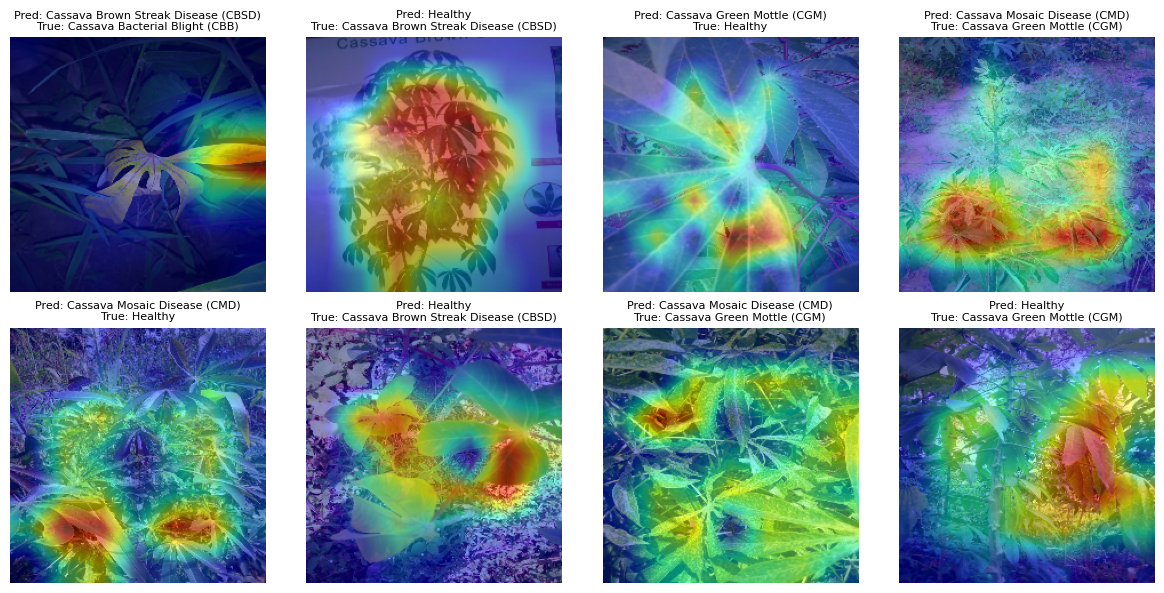

In [25]:
true_labels_arr = np.array(best_res['labels'])
pred_labels_arr = np.array(best_res['preds'])

misclassified_mask  = true_labels_arr != pred_labels_arr
misclassified_positions = np.where(misclassified_mask)[0]

total = len(true_labels_arr)
n_err = len(misclassified_positions)
print(f'Misclassified: {n_err:,} / {total:,} ({n_err / total * 100:.1f}%)')
print(f'Correctly classified: {total - n_err:,} ({(total - n_err) / total * 100:.1f}%)')

n_show = min(8, len(misclassified_positions))
error_rng = np.random.RandomState(SEED)
show_positions = error_rng.choice(misclassified_positions, n_show, replace=False)

err_images, err_true_labels = [], []
for pos in show_positions:
    row = split_df['test'].iloc[pos]
    img = cv2.imread(str(IMAGE_DIR / row['image_id']))
    if img is not None:
        err_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        err_true_labels.append(int(row['label']))

if err_images:
    print(f'\nGrad-CAM overlays for {len(err_images)} misclassified samples:')
    show_gradcam_grid(
        model       = best_model_vis,
        model_name  = best_arch,
        images      = err_images,
        image_size  = INPUT_SIZE,
        class_names = disease_names,
        device      = DEVICE,
        true_labels = err_true_labels,
        cols        = 4,
    )
else:
    print('No misclassified samples to visualize.')

In-Depth Error Analysis — EfficientNet-V2-S

Top confused class pairs:
True Class                                 Predicted As                                Count
--------------------------------------------------------------------------------------------
Cassava Green Mottle (CGM)                 Cassava Mosaic Disease (CMD)                  80  (20.8% of errors)
Cassava Green Mottle (CGM)                 Healthy                                       56  (14.5% of errors)
Cassava Bacterial Blight (CBB)             Healthy                                       51  (13.2% of errors)
Cassava Brown Streak Disease (CBSD)        Healthy                                       51  (13.2% of errors)
Cassava Brown Streak Disease (CBSD)        Cassava Mosaic Disease (CMD)                  35  (9.1% of errors)
Cassava Mosaic Disease (CMD)               Healthy                                       35  (9.1% of errors)
Healthy                                    Cassava Mosaic Disease (CMD)        

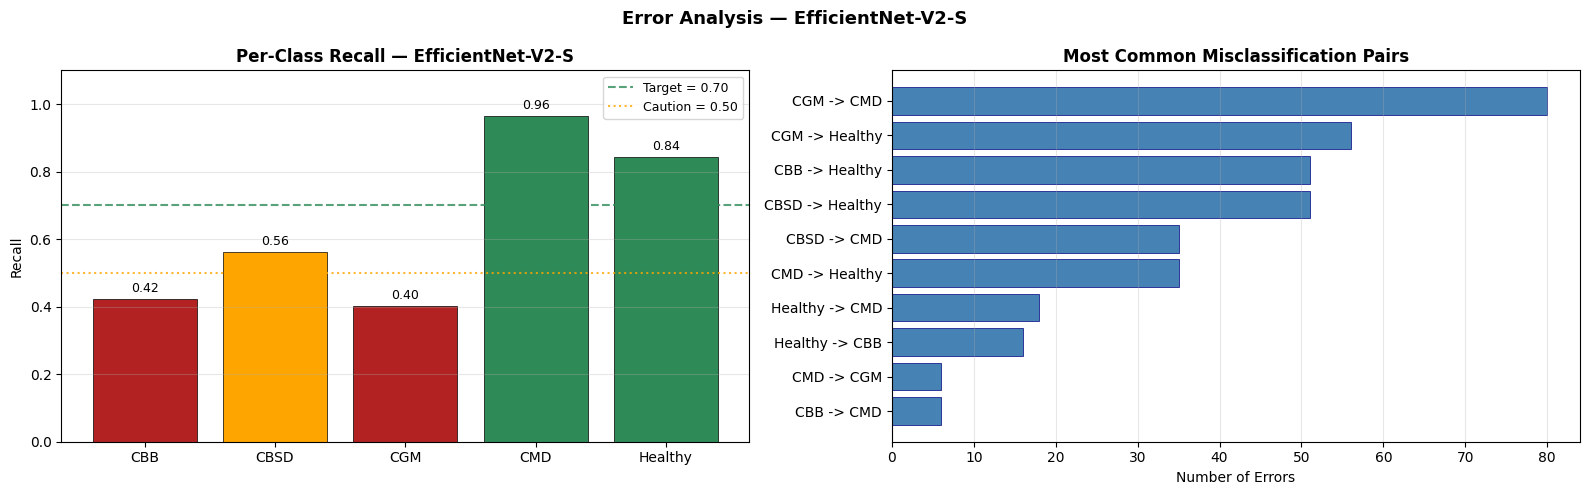


Saved error analysis plot to: /Users/mulatyazewchekol/Documents/My_Projects/Final_Projects/cassava-multitask-vision/results/error_analysis.png


In [26]:
print(f'In-Depth Error Analysis — {best_nm}')
print('=' * 70)

conf_counts = {}
err_mask = true_labels_arr != pred_labels_arr
for tc, pc in zip(true_labels_arr[err_mask], pred_labels_arr[err_mask]):
    key = (int(tc), int(pc))
    conf_counts[key] = conf_counts.get(key, 0) + 1

sorted_pairs = sorted(conf_counts.items(), key=lambda x: -x[1])

print(f'\nTop confused class pairs:')
print(f'{"True Class":<42} {"Predicted As":<42} {"Count":>6}')
print('-' * 92)
for (tc, pc), cnt in sorted_pairs[:12]:
    tname = disease_names.get(tc, f'Class {tc}')
    pname = disease_names.get(pc, f'Class {pc}')
    pct   = cnt / n_err * 100
    print(f'{tname:<42} {pname:<42} {cnt:>5}  ({pct:.1f}% of errors)')

print()
print('Per-class recall:')
recalls, short_names_rc, bar_colors_rc = [], [], []
for c in range(NUM_CLASSES):
    mask = true_labels_arr == c
    if mask.sum() == 0:
        continue
    rec  = float((pred_labels_arr[mask] == c).mean())
    name = disease_names.get(c, f'Class {c}')
    abbr = name.split('(')[-1].rstrip(')') if '(' in name else name
    recalls.append(rec)
    short_names_rc.append(abbr)
    color = 'seagreen' if rec >= 0.70 else ('orange' if rec >= 0.50 else 'firebrick')
    bar_colors_rc.append(color)
    print(f'  {name:<42s}  recall={rec:.3f}')

fig, axes_err = plt.subplots(1, 2, figsize=(16, 5))

axes_err[0].bar(short_names_rc, recalls, color=bar_colors_rc, edgecolor='black', linewidth=0.5)
axes_err[0].axhline(0.70, color='seagreen', linestyle='--', alpha=0.8, label='Target = 0.70')
axes_err[0].axhline(0.50, color='orange',   linestyle=':', alpha=0.8, label='Caution = 0.50')
axes_err[0].set_ylim(0, 1.1)
axes_err[0].set_ylabel('Recall')
axes_err[0].set_title(f'Per-Class Recall — {best_nm}', fontweight='bold')
axes_err[0].legend(fontsize=9)
axes_err[0].grid(True, alpha=0.3, axis='y')
for i, val in enumerate(recalls):
    axes_err[0].text(i, val + 0.02, f'{val:.2f}', ha='center', fontsize=9)

top_n = min(10, len(sorted_pairs))
pair_labels = []
pair_counts = []
for (tc, pc), cnt in sorted_pairs[:top_n]:
    ta = disease_names.get(tc, f'C{tc}').split('(')[-1].rstrip(')') if '(' in disease_names.get(tc,'') else disease_names.get(tc,'')
    pa = disease_names.get(pc, f'C{pc}').split('(')[-1].rstrip(')') if '(' in disease_names.get(pc,'') else disease_names.get(pc,'')
    pair_labels.append(f'{ta} -> {pa}')
    pair_counts.append(cnt)

axes_err[1].barh(pair_labels[::-1], pair_counts[::-1], color='steelblue', edgecolor='navy', linewidth=0.5)
axes_err[1].set_xlabel('Number of Errors')
axes_err[1].set_title('Most Common Misclassification Pairs', fontweight='bold')
axes_err[1].grid(True, alpha=0.3, axis='x')

plt.suptitle(f'Error Analysis — {best_nm}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'error_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nSaved error analysis plot to: {RESULTS_DIR / "error_analysis.png"}')